In [46]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import *
from pathlib import Path
from utils.colors import C2, M, MS
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit
from utils.mesh_utils import get_L_mesh, get_donut_mesh

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [47]:
from utils.problem_setup import TestProblemsSetup

def get_S(n, pid):
    setup = TestProblemsSetup(n)
    pb = setup.get_single_problem(pid)

    # Generate  exact K and K*
    exact = ExactForwardOperator(pb['V_h'])
    K = exact.K
    U, S, Vt = np.linalg.svd(K, full_matrices=False)

    M, M_d = exact.M_dx, exact.M_ds
    K_star = np.linalg.inv(M) @ K.T @ M_d

    Us, Ss, Vst = np.linalg.svd(K_star, full_matrices=False)
    return S, Ss



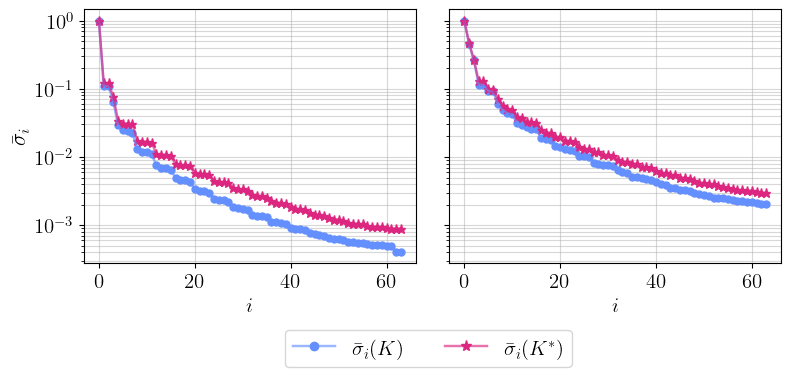

In [77]:
from utils.plotting import save_plot
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3), sharey=True)

upper = 64

for i, pid in enumerate(['I', 'III']):
    ax = axes[i]
    S, Ss = get_S(16, pid=pid)


    S_norm = S / np.max(S)
    Ss_norm = Ss / np.max(Ss)

    ax.semilogy(S_norm[:upper],  M[0], c=C2[0], ms=5)
    ax.semilogy(Ss_norm[:upper], M[1], c=C2[1], ms=6.5)

    ax.semilogy(S_norm[:upper], '-',  c=C2[0], alpha=0.65, lw=1.75)
    ax.semilogy(Ss_norm[:upper], '-', c=C2[1], alpha=0.65, lw=1.75)

    ax.set_xlabel("$i$")
    ax.grid(True, alpha=0.5, which='both')

from matplotlib.lines import Line2D
handles, labels = [], ['$\\bar \sigma_i(K)$', '$\\bar \sigma_i(K^*)$']
for i in range(2):
    legend_line = Line2D([0], [0], color=C2[i], linewidth=1.75, alpha=.65)
    legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
    handles.append((legend_line, legend_marker))

axes[0].set_ylabel("$\\bar \sigma_i$", fontsize=16)
axes[0].legend(handles=handles, labels=labels, bbox_to_anchor=(1.5,-0.22), ncols=2)

plt.subplots_adjust(wspace=0.1)
save_plot('true_singular_values')

plt.show()